# Skenario C: Multi-Site AmeriFlux + Fitur Tanah Statis

Notebook ini memperluas eksperimen ke `US-Ne1`, `US-Ne2`, dan `US-Ne3` agar model belajar dari variasi antar lahan. Pipeline ini juga memakai **fitur inti** saja supaya jumlah baris bersih tidak runtuh seperti pada Skenario B.

Fokus utama:
- menggabungkan beberapa site AmeriFlux secara konsisten,
- menambahkan `site_id` sebagai fitur kategorikal,
- memasukkan fitur tanah statis per site,
- melakukan split kronologis per site,
- membandingkan hasil dengan baseline `R2 = 0.613`.

> Catatan: saat notebook ini dibuat, file `US-Ne2` dan `US-Ne3` belum ada di workspace. Pipeline tetap siap dipakai dan akan memberi peringatan yang jelas jika file belum tersedia.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

pd.set_option('display.max_columns', 200)


In [ ]:
# =========================
# Configuration
# =========================
BASELINE_R2_A = 0.613
TRAIN_RATIO = 0.8

SITE_CONFIG = {
    'US-Ne1': {
        'csv_path': Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\AmeriFlux\AMF_US-Ne1_FLUXNET_2001-2024_v1.3_r1\AMF_US-Ne1_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv'),
        'lat': 41.165,
        'lon': -96.476,
    },
    'US-Ne2': {
        'csv_path': Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\AmeriFlux\AMF_US-Ne2_FLUXNET_2001-2024_v1.3_r1\AMF_US-Ne2_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv'),
        'lat': 41.1649,
        'lon': -96.4701,
    },
    'US-Ne3': {
        'csv_path': Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\AmeriFlux\AMF_US-Ne3_FLUXNET_2001-2024_v1.3_r1\AMF_US-Ne3_FLUXNET_FLUXMET_HR_2001-2024_v1.3_r1.csv'),
        'lat': 41.1797,
        'lon': -96.4397,
    },
}

WOSIS_PH_PATH = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\WoSIS (ISRIC)\wosis_latest_PH.csv')
WOSIS_ORGC_PATH = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\dataset\WoSIS (ISRIC)\wosis_latest_orgc.csv')
MANUAL_SITE_SOIL_CSV = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\skenario-c\manual_site_soil.csv')
MANUAL_SITE_SOIL_TEMPLATE_CSV = Path(r'D:\Tugas Kuliah\Semester 6\MBKM - Magang\carbon\code-dataset-3\skenario-c\manual_site_soil_template.csv')

# Isi dictionary ini bila Anda sudah punya hasil spatial join WoSIS yang valid per site.
# Dengan nilai manual per site, fitur tanah statis akan benar-benar bervariasi antar lahan.
MANUAL_SITE_SOIL = {
    # 'US-Ne1': {'soil_ph': 6.10, 'soil_organic_carbon': 18.20},
    # 'US-Ne2': {'soil_ph': 6.35, 'soil_organic_carbon': 21.50},
    # 'US-Ne3': {'soil_ph': 5.95, 'soil_organic_carbon': 16.80},
}


In [3]:
# =========================
# Utility Functions
# =========================
def evaluate_regression(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }


def detect_first_available(columns, candidates):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None


def add_cyclical_time_features(df):
    out = df.copy()
    out['hour_sin'] = np.sin(2 * np.pi * out['hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['hour'] / 24)
    out['doy_sin'] = np.sin(2 * np.pi * out['day_of_year'] / 365.25)
    out['doy_cos'] = np.cos(2 * np.pi * out['day_of_year'] / 365.25)
    return out


def resolve_available_sites(site_config):
    available = {}
    missing = {}
    for site_id, cfg in site_config.items():
        if cfg['csv_path'].exists():
            available[site_id] = cfg
        else:
            missing[site_id] = cfg['csv_path']
    return available, missing


def load_manual_site_soil_csv(csv_path):
    if not csv_path.exists():
        return {}

    df = pd.read_csv(csv_path)
    required_cols = {'site_id', 'soil_ph', 'soil_organic_carbon'}
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(f'Kolom wajib pada {csv_path.name} belum lengkap: {sorted(missing_cols)}')

    work = df.copy()
    work['soil_ph'] = pd.to_numeric(work['soil_ph'], errors='coerce')
    work['soil_organic_carbon'] = pd.to_numeric(work['soil_organic_carbon'], errors='coerce')
    work = work.dropna(subset=['site_id', 'soil_ph', 'soil_organic_carbon'])

    result = {}
    for _, row in work.iterrows():
        result[str(row['site_id'])] = {
            'soil_ph': float(row['soil_ph']),
            'soil_organic_carbon': float(row['soil_organic_carbon']),
        }
    return result


def plot_feature_importance(model, feature_names, title='Feature Importance'):
    if not hasattr(model, 'feature_importances_'):
        raise ValueError('Model tidak memiliki atribut feature_importances_.')

    fi_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi_df.head(20), x='importance', y='feature', orient='h')
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return fi_df


In [4]:
# =========================
# Data Preparation Functions
# =========================
def load_ameriflux_core(csv_path, site_id):
    raw_df = pd.read_csv(csv_path)
    df = raw_df.replace(-9999, np.nan).copy()

    target_col = detect_first_available(df.columns, ['NEE_VUT_REF', 'FC_F', 'FC'])
    selected = {
        'air_temperature_c': detect_first_available(df.columns, ['TA_F', 'TA_F_MDS']),
        'relative_humidity': detect_first_available(df.columns, ['RH']),
        'soil_temperature_c': detect_first_available(df.columns, ['TS_F_MDS_1', 'TS_F_MDS_2']),
        'soil_water_content': detect_first_available(df.columns, ['SWC_F_MDS_1', 'SWC_F_MDS_2']),
        'solar_radiation': detect_first_available(df.columns, ['SW_IN_F', 'SW_IN_F_MDS', 'SW_IN']),
        'vpd_kpa': detect_first_available(df.columns, ['VPD_F', 'VPD_F_MDS']),
    }

    missing_required = [name for name, col in selected.items() if col is None]
    if target_col is None:
        raise ValueError(f'Kolom target tidak ditemukan untuk {site_id}.')
    if missing_required:
        raise ValueError(f'Kolom inti hilang untuk {site_id}: {missing_required}')

    keep_cols = ['TIMESTAMP_START', target_col] + list(selected.values())
    work = df[keep_cols].copy()
    rename_map = {'TIMESTAMP_START': 'reading_time', target_col: 'carbon_flux'}
    rename_map.update({v: k for k, v in selected.items()})
    work = work.rename(columns=rename_map)

    work['reading_time'] = pd.to_datetime(work['reading_time'], format='%Y%m%d%H%M', errors='coerce')
    work['hour'] = work['reading_time'].dt.hour
    work['day_of_year'] = work['reading_time'].dt.dayofyear
    work['month'] = work['reading_time'].dt.month
    work['site_id'] = site_id
    work = add_cyclical_time_features(work)

    required_cols = [
        'reading_time', 'carbon_flux', 'air_temperature_c', 'relative_humidity',
        'soil_temperature_c', 'soil_water_content', 'solar_radiation', 'vpd_kpa',
        'hour', 'day_of_year', 'month', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'
    ]
    clean_df = work.dropna(subset=required_cols).sort_values('reading_time').reset_index(drop=True)

    print(f'[{site_id}] Raw shape  : {raw_df.shape}')
    print(f'[{site_id}] Clean shape: {clean_df.shape}')
    print(f'[{site_id}] Target col : {target_col}')
    print(f'[{site_id}] Features   : {selected}')
    print('-' * 80)

    return clean_df


def extract_wosis_fallback_value(wosis_path, prefer_country='United States'):
    df = pd.read_csv(wosis_path)
    value_col = detect_first_available(df.columns, ['value_avg', 'value', 'mean_value'])
    country_col = detect_first_available(df.columns, ['country_name', 'country'])
    upper_depth_col = detect_first_available(df.columns, ['upper_depth', 'top_depth'])
    lower_depth_col = detect_first_available(df.columns, ['lower_depth', 'bottom_depth'])

    if value_col is None:
        raise ValueError(f'Kolom nilai tidak ditemukan di {wosis_path.name}.')

    work = df.copy()
    work[value_col] = pd.to_numeric(work[value_col], errors='coerce')
    work = work.dropna(subset=[value_col])

    if upper_depth_col and lower_depth_col:
        work[upper_depth_col] = pd.to_numeric(work[upper_depth_col], errors='coerce')
        work[lower_depth_col] = pd.to_numeric(work[lower_depth_col], errors='coerce')
        work = work[(work[upper_depth_col] < 30) & (work[lower_depth_col] <= 30)]

    if country_col is not None:
        subset = work[work[country_col].astype(str).str.contains(prefer_country, case=False, na=False)]
        if not subset.empty:
            return float(subset[value_col].mean()), f'country-average ({prefer_country})'

    return float(work[value_col].mean()), 'global-average'


def build_site_soil_lookup(site_ids, manual_site_soil, wosis_ph_path, wosis_orgc_path):
    fallback_ph, ph_source = extract_wosis_fallback_value(wosis_ph_path)
    fallback_orgc, orgc_source = extract_wosis_fallback_value(wosis_orgc_path)

    soil_lookup = {}
    for site_id in site_ids:
        manual = manual_site_soil.get(site_id, {})
        soil_lookup[site_id] = {
            'soil_ph': float(manual.get('soil_ph', fallback_ph)),
            'soil_organic_carbon': float(manual.get('soil_organic_carbon', fallback_orgc)),
            'soil_source': 'manual' if manual else f'fallback: {ph_source} / {orgc_source}',
        }
    return soil_lookup


def attach_static_soil_features(df, soil_lookup):
    lookup_df = pd.DataFrame.from_dict(soil_lookup, orient='index').reset_index().rename(columns={'index': 'site_id'})
    merged = df.merge(lookup_df, on='site_id', how='left')
    if merged[['soil_ph', 'soil_organic_carbon']].isna().any().any():
        raise ValueError('Ada site tanpa nilai soil statis setelah merge.')
    return merged


def chronological_split_by_site(df, feature_cols, target_col='carbon_flux', train_ratio=0.8):
    train_parts = []
    test_parts = []

    for site_id, site_df in df.sort_values('reading_time').groupby('site_id', sort=False):
        site_df = site_df.sort_values('reading_time').reset_index(drop=True)
        n_train = int(len(site_df) * train_ratio)
        train_parts.append(site_df.iloc[:n_train].copy())
        test_parts.append(site_df.iloc[n_train:].copy())
        print(f'[{site_id}] Train rows: {n_train}, Test rows: {len(site_df) - n_train}')

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    return X_train, y_train, X_test, y_test, train_df, test_df


In [5]:
# =========================
# Run Scenario C Pipeline
# =========================
available_sites, missing_sites = resolve_available_sites(SITE_CONFIG)
print('Available sites:', list(available_sites.keys()))
if missing_sites:
    print('Missing site files:')
    for site_id, missing_path in missing_sites.items():
        print(f'- {site_id}: {missing_path}')

site_frames = []
for site_id, cfg in available_sites.items():
    site_frames.append(load_ameriflux_core(cfg['csv_path'], site_id))

if not site_frames:
    raise FileNotFoundError('Tidak ada file AmeriFlux yang ditemukan untuk Skenario C.')

scenario_c_df = pd.concat(site_frames, ignore_index=True)
manual_site_soil_from_csv = load_manual_site_soil_csv(MANUAL_SITE_SOIL_CSV)
manual_site_soil_final = {**MANUAL_SITE_SOIL, **manual_site_soil_from_csv}
soil_lookup = build_site_soil_lookup(list(available_sites.keys()), manual_site_soil_final, WOSIS_PH_PATH, WOSIS_ORGC_PATH)
scenario_c_df = attach_static_soil_features(scenario_c_df, soil_lookup)

print('\nSoil lookup per site:')
display(pd.DataFrame.from_dict(soil_lookup, orient='index'))

if len(available_sites) < 2:
    print('\nWARNING: Workspace saat ini belum punya minimal 2 site. Notebook tetap jalan, tetapi hasilnya belum mewakili eksperimen multi-site penuh.')
print(f'Manual soil CSV path: {MANUAL_SITE_SOIL_CSV}')
if manual_site_soil_from_csv:
    print('Manual soil values loaded from CSV:', sorted(manual_site_soil_from_csv.keys()))
else:
    print(f'INFO: File manual soil CSV belum ada atau masih kosong. Gunakan template: {MANUAL_SITE_SOIL_TEMPLATE_CSV}')

if len(manual_site_soil_final) < len(available_sites):
    print('WARNING: Nilai soil statis masih memakai fallback yang sama untuk sebagian atau seluruh site. Isi MANUAL_SITE_SOIL atau manual_site_soil.csv setelah spatial join WoSIS agar fitur statis benar-benar informatif.')

site_dummies = pd.get_dummies(scenario_c_df['site_id'], prefix='site')
scenario_c_model_df = pd.concat([scenario_c_df.drop(columns=['site_id']), site_dummies], axis=1)

feature_cols = [
    'air_temperature_c', 'relative_humidity', 'soil_temperature_c',
    'soil_water_content', 'solar_radiation', 'vpd_kpa',
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'month',
    'soil_ph', 'soil_organic_carbon'
] + site_dummies.columns.tolist()

X_train, y_train, X_test, y_test, train_df, test_df = chronological_split_by_site(
    pd.concat([scenario_c_df[['site_id', 'reading_time', 'carbon_flux']], scenario_c_model_df[feature_cols]], axis=1),
    feature_cols=feature_cols,
    target_col='carbon_flux',
    train_ratio=TRAIN_RATIO,
)

rf_model_c = RandomForestRegressor(
    n_estimators=400,
    max_depth=18,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1,
)
rf_model_c.fit(X_train, y_train)
y_pred_c = rf_model_c.predict(X_test)
metrics_c = evaluate_regression(y_test, y_pred_c)

print('\n=== Evaluasi Skenario C (RandomForest multi-site) ===')
print(f"MAE : {metrics_c['MAE']:.4f}")
print(f"RMSE: {metrics_c['RMSE']:.4f}")
print(f"R2  : {metrics_c['R2']:.4f}")

delta_r2 = metrics_c['R2'] - BASELINE_R2_A
print('\n=== Perbandingan dengan Baseline Skenario A ===')
print(f'R2 Baseline A: {BASELINE_R2_A:.3f}')
print(f"R2 Skenario C: {metrics_c['R2']:.4f}")
print(f'Perubahan R2 : {delta_r2:+.4f}')

if delta_r2 > 0:
    print('Kesimpulan: strategi multi-site meningkatkan performa terhadap baseline.')
elif delta_r2 < 0:
    print('Kesimpulan: strategi multi-site pada setup saat ini masih di bawah baseline.')
else:
    print('Kesimpulan: belum ada perubahan performa terhadap baseline.')


Available sites: ['US-Ne1', 'US-Ne2', 'US-Ne3']
[US-Ne1] Raw shape  : (210384, 241)
[US-Ne1] Clean shape: (206242, 16)
[US-Ne1] Target col : NEE_VUT_REF
[US-Ne1] Features   : {'air_temperature_c': 'TA_F', 'relative_humidity': 'RH', 'soil_temperature_c': 'TS_F_MDS_1', 'soil_water_content': 'SWC_F_MDS_1', 'solar_radiation': 'SW_IN_F', 'vpd_kpa': 'VPD_F'}
--------------------------------------------------------------------------------
[US-Ne2] Raw shape  : (210384, 241)
[US-Ne2] Clean shape: (195141, 16)
[US-Ne2] Target col : NEE_VUT_REF
[US-Ne2] Features   : {'air_temperature_c': 'TA_F', 'relative_humidity': 'RH', 'soil_temperature_c': 'TS_F_MDS_1', 'soil_water_content': 'SWC_F_MDS_1', 'solar_radiation': 'SW_IN_F', 'vpd_kpa': 'VPD_F'}
--------------------------------------------------------------------------------
[US-Ne3] Raw shape  : (210384, 243)
[US-Ne3] Clean shape: (201509, 16)
[US-Ne3] Target col : NEE_VUT_REF
[US-Ne3] Features   : {'air_temperature_c': 'TA_F', 'relative_humidity'

,soil_ph,soil_organic_carbon,soil_source
US-Ne1,5.992126,19.63971,fallback: country-average (United States) / gl...
US-Ne2,5.992126,19.63971,fallback: country-average (United States) / gl...
US-Ne3,5.992126,19.63971,fallback: country-average (United States) / gl...


[US-Ne1] Train rows: 164993, Test rows: 41249
[US-Ne2] Train rows: 156112, Test rows: 39029
[US-Ne3] Train rows: 161207, Test rows: 40302

=== Evaluasi Skenario C (RandomForest multi-site) ===
MAE : 2.0263
RMSE: 4.6170
R2  : 0.8135

=== Perbandingan dengan Baseline Skenario A ===
R2 Baseline A: 0.613
R2 Skenario C: 0.8135
Perubahan R2 : +0.2005
Kesimpulan: strategi multi-site meningkatkan performa terhadap baseline.


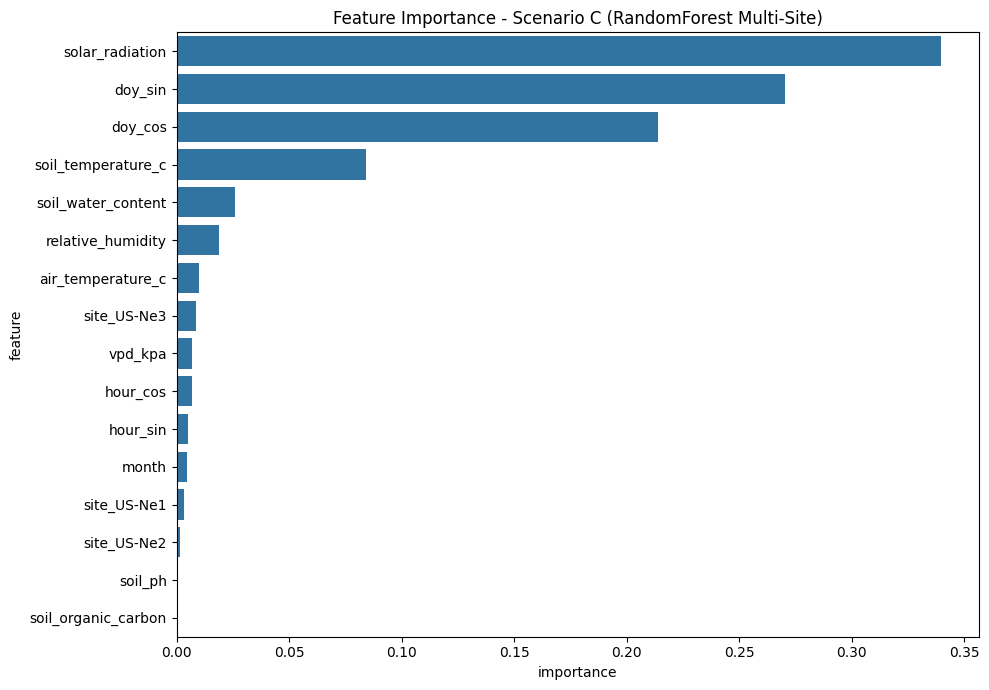

,feature,importance
4,solar_radiation,0.339812
8,doy_sin,0.270547
9,doy_cos,0.213833
2,soil_temperature_c,0.084090
3,soil_water_content,0.025893
1,relative_humidity,0.018847
0,air_temperature_c,0.010083
15,site_US-Ne3,0.008586
5,vpd_kpa,0.006774
7,hour_cos,0.006689


In [6]:
# Feature importance Skenario C
fi_c = plot_feature_importance(
    rf_model_c,
    feature_names=feature_cols,
    title='Feature Importance - Scenario C (RandomForest Multi-Site)'
)

fi_c.head(20)
